In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
Sales_Data=pd.read_csv("Amazon_data.csv")
Sales_Data.head()


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,13-04-2022,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176
1,2,12-03-2023,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520
2,3,28-09-2022,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664
3,4,17-04-2022,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232
4,5,13-03-2022,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336


In [4]:
Sales_Data.shape

(50000, 14)

In [5]:
Sales_Data.nunique()

order_id            50000
order_date            730
product_id           4000
product_category        6
price               31465
discount_percent        6
quantity_sold           5
customer_region         4
payment_method          5
rating                 41
review_count          500
discounted_price    30356
total_revenue       39768
profit              39768
dtype: int64

In [6]:
Sales_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
 13  profit            50000 non-null  float64
dtypes: float64(5), int64(5), object(4)
memory usage: 5.3+ MB


In [7]:
Sales_Data.describe().round(2)

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue,profit
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,25000.50,2986.85,252.51,13.34,3.00,3.00,249.33,218.89,657.33,32.87
std,14433.90,1156.37,143.03,9.85,1.42,1.15,144.25,127.32,526.22,26.31
min,1.00,1000.00,5.01,0.00,1.00,1.00,0.00,3.53,3.84,0.19
25%,12500.75,1983.00,127.84,5.00,2.00,2.00,125.00,109.68,240.32,12.02
50%,25000.50,2983.00,252.97,10.00,3.00,3.00,250.00,215.80,505.41,25.27
75%,37500.25,3989.00,376.34,20.00,4.00,4.00,374.00,322.70,968.97,48.45
max,50000.00,4999.00,499.99,30.00,5.00,5.00,499.00,499.91,2499.55,124.98


In [8]:
Sales_Data.dtypes

order_id              int64
order_date           object
product_id            int64
product_category     object
price               float64
discount_percent      int64
quantity_sold         int64
customer_region      object
payment_method       object
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
profit              float64
dtype: object

In [9]:
Sales_Data.isna().any()

order_id            False
order_date          False
product_id          False
product_category    False
price               False
discount_percent    False
quantity_sold       False
customer_region     False
payment_method      False
rating              False
review_count        False
discounted_price    False
total_revenue       False
profit              False
dtype: bool

In [10]:
Sales_Data["order_date"]=pd.to_datetime(Sales_Data["order_date"],errors="coerce")
Sales_Data.rename(columns={"product_category":"product_name"},inplace=True)
Sales_Data.drop_duplicates(inplace=True)
Sales_Data.dropna(inplace=True)
Sales_Data.dtypes

C:\Users\sanjay\AppData\Local\Temp\ipykernel_2008\2469827088.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  Sales_Data["order_date"]=pd.to_datetime(Sales_Data["order_date"],errors="coerce")


order_id                     int64
order_date          datetime64[ns]
product_id                   int64
product_name                object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
profit                     float64
dtype: object

In [11]:
Sales_Data.drop_duplicates(inplace=True)
Sales_Data.dropna(inplace=True)
Sales_Data.shape

(50000, 14)

In [48]:
Sales_Data.head()

,order_id,order_date,product_id,product_name,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3,443,115.88,463.52,23.176
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3,475,242.08,1210.40,60.520
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4,183,396.64,793.28,39.664
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5,212,316.16,1264.64,63.232
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4,308,201.68,806.72,40.336


In [58]:
Sales_Data.groupby(by=["customer_region","payment_method"])["total_revenue"].sum().round(1)

customer_region  payment_method  
Asia             Cash on Delivery    1605814.5
                 Credit Card         1645411.0
                 Debit Card          1600035.4
                 UPI                 1707818.8
                 Wallet              1616120.1
Europe           Cash on Delivery    1591031.6
                 Credit Card         1590127.1
                 Debit Card          1624715.8
                 UPI                 1633469.5
                 Wallet              1672967.5
Middle East      Cash on Delivery    1707805.8
                 Credit Card         1680879.2
                 Debit Card          1641435.1
                 UPI                 1591712.8
                 Wallet              1680011.6
North America    Cash on Delivery    1641735.0
                 Credit Card         1623669.8
                 Debit Card          1655833.4
                 UPI                 1646440.4
                 Wallet              1709539.3
Name: total_revenue, dtype

In [62]:
pd.crosstab(index=Sales_Data["customer_region"],columns=Sales_Data["quantity_sold"],margins=True)

quantity_sold,1,2,3,4,5,All
customer_region,,,,,,
Asia,2582,2452,2513,2480,2499,12526
Europe,2560,2420,2492,2474,2506,12452
Middle East,2420,2523,2536,2510,2516,12505
North America,2498,2519,2485,2532,2483,12517
All,10060,9914,10026,9996,10004,50000


In [63]:
pd.crosstab(index=Sales_Data["customer_region"],columns=Sales_Data["product_name"],margins=True)

product_name,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports,All
customer_region,,,,,,,
Asia,2101,2164,2091,2026,2077,2067,12526
Europe,2110,2036,2082,2137,2025,2062,12452
Middle East,2092,2113,2064,2096,2080,2060,12505
North America,2162,2014,2083,2106,2076,2076,12517
All,8465,8327,8320,8365,8258,8265,50000


Text(0, 0.5, 'Discount Price')

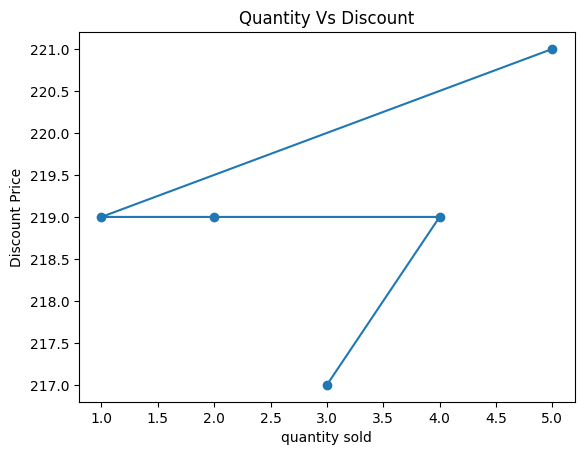

In [28]:
x=Sales_Data.groupby(by="quantity_sold")["discounted_price"].mean().sort_values(ascending=False).round()
plt.plot(x,marker="o")
plt.title("Quantity Vs Discount")
plt.xlabel("quantity sold")
plt.ylabel("Discount Price")

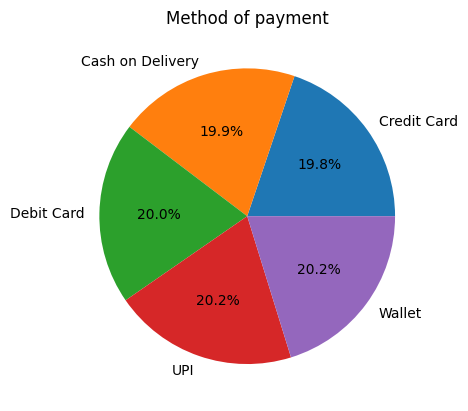

In [31]:
Total_Country=Sales_Data.payment_method.value_counts().sort_values()
plt.pie(Total_Country,labels=Total_Country.index,autopct='%1.1f%%')
plt.title("Method of payment")
plt.show()

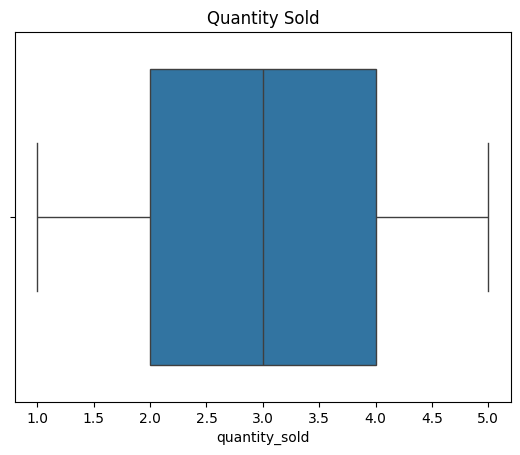

In [32]:
sns.boxplot(x=Sales_Data["quantity_sold"])
plt.title("Quantity Sold")
plt.show()

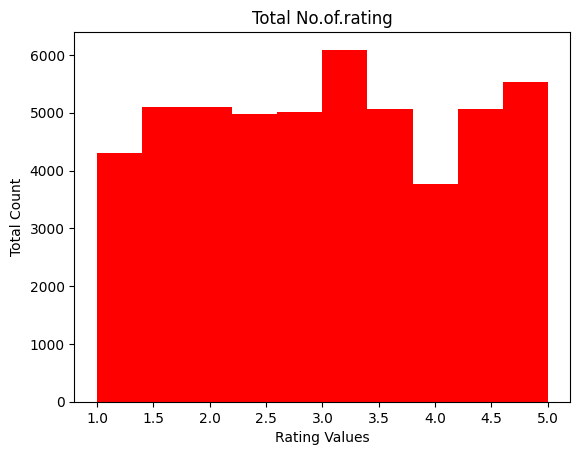

In [33]:
plt.hist(x=Sales_Data["rating"],color="r")
plt.title("Total No.of.rating")
plt.xlabel("Rating Values")
plt.ylabel("Total Count")
plt.show()

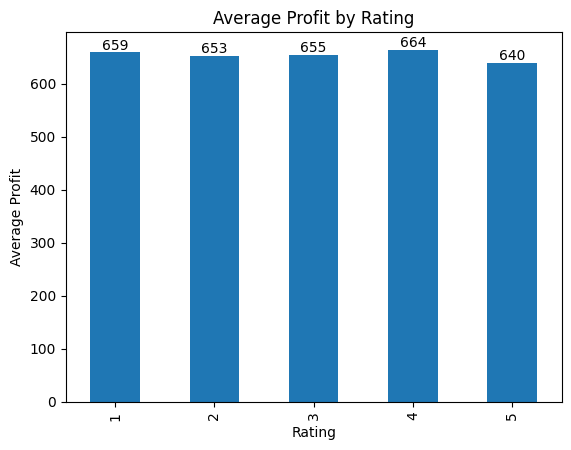

In [34]:
Sales_Data["rating"] = Sales_Data["rating"].astype(int)
avg_profit = Sales_Data.groupby("rating")["total_revenue"].mean().round()
Total_rating=avg_profit.plot(kind="bar")
Total_rating.bar_label(Total_rating.containers[0]) 
plt.xlabel("Rating")
plt.ylabel("Average Profit")
plt.title("Average Profit by Rating")
plt.show()

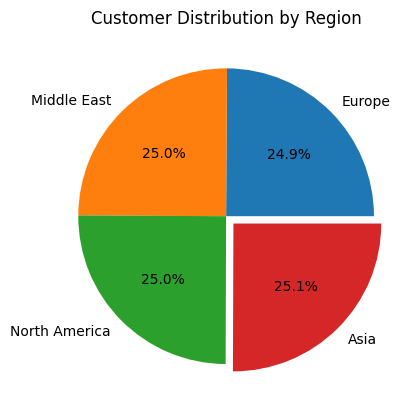

In [35]:
Total_Country=Sales_Data.customer_region.value_counts().sort_values()
explode=[0,0,0,0.07]
plt.pie(Total_Country,labels=Total_Country.index,explode=explode,autopct='%1.1f%%')
plt.title("Customer Distribution by Region")
plt.show()




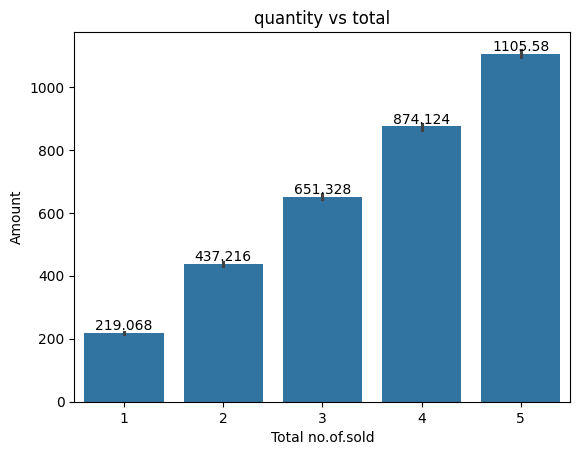

In [36]:
Total_quantity = sns.barplot(data=Sales_Data, x="quantity_sold", y="total_revenue")
Total_quantity.bar_label(Total_quantity.containers[0]) 
plt.title("quantity vs total")
plt.xlabel("Total no.of.sold")
plt.ylabel("Amount")
plt.show()

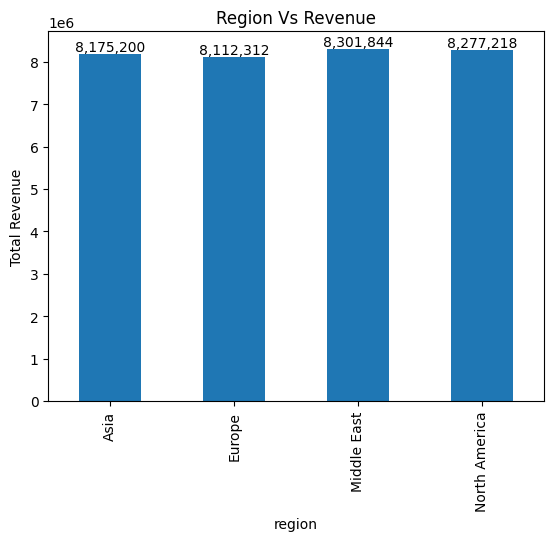

In [45]:
import matplotlib.pyplot as plt
region_data = Sales_Data.groupby("customer_region")["total_revenue"].sum()
Final = region_data.plot(kind="bar")
for i, v in enumerate(region_data):
    Final.text(i, v, f"{v:,.0f}", ha='center', va='bottom')
plt.title("Region Vs Revenue")
plt.xlabel("region")
plt.ylabel("Total Revenue")
plt.show()


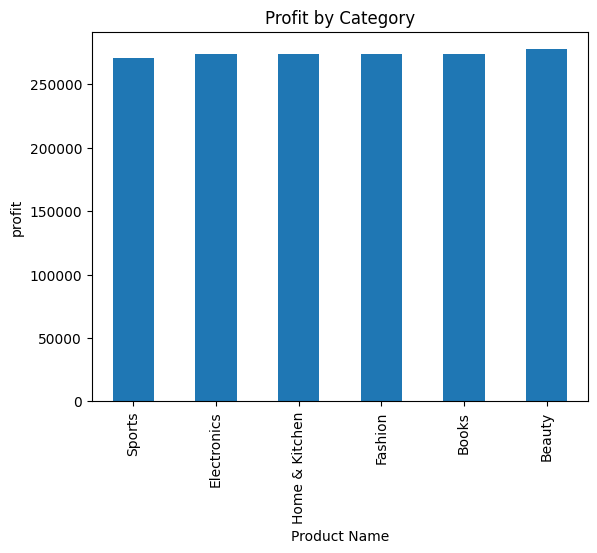

In [41]:
profit_data = Sales_Data.groupby("product_name")["profit"].sum().sort_values()
profit_data.plot(kind="bar", title="Profit by Category")
plt.xlabel("Product Name")
plt.ylabel("profit")
plt.show()

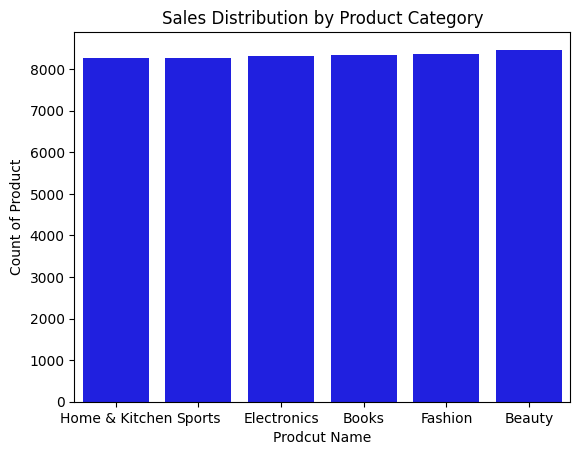

In [42]:
Total_product=Sales_Data.product_name.value_counts().sort_values()
sns.barplot(Total_product,color="blue")
plt.title("Sales Distribution by Product Category")
plt.xlabel("Prodcut Name")
plt.ylabel("Count of Product")
plt.show()


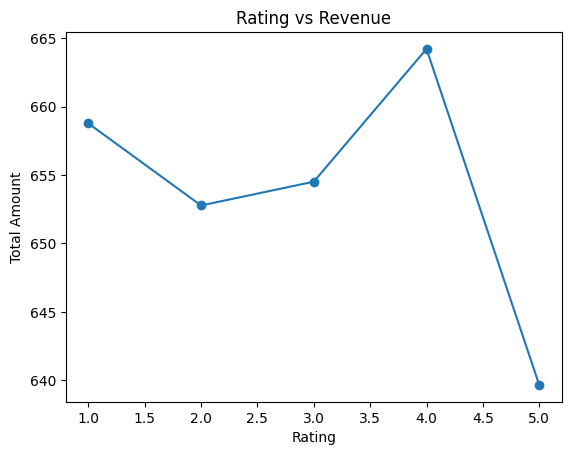

In [44]:
rating_data = Sales_Data.groupby("rating")["total_revenue"].mean()
rating_data.plot(kind="line", marker='o', title="Rating vs Revenue")
plt.xlabel("Rating")
plt.ylabel("Total Amount")
plt.show()